<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Respiration_Rate_PF_Included.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ANOVA P-value: 0.1684


/tmp/ipython-input-569324326.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


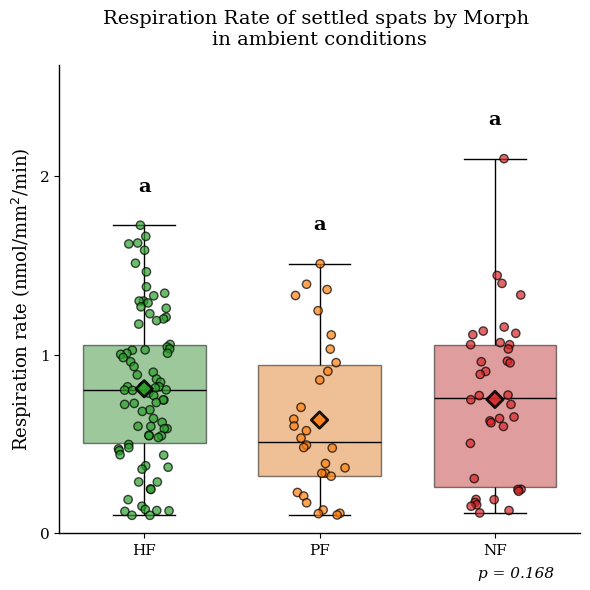

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import matplotlib.ticker as ticker

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
filename = 'Ambient_Spat_Resp_Final.csv'
df_resp = pd.read_csv(filename)

# Filter for the relevant morphs (just in case)
target_morphs = ['HF', 'PF', 'NF']
df_resp = df_resp[df_resp['Morph'].isin(target_morphs)]

# ==========================================
# 2. STATISTICS (One-Way ANOVA)
# ==========================================
# We use ANOVA because we now have 3 groups (HF, PF, NF)
hf_vals = df_resp[df_resp['Morph'] == 'HF']['OxyRate nmol/mm2/min']
pf_vals = df_resp[df_resp['Morph'] == 'PF']['OxyRate nmol/mm2/min']
nf_vals = df_resp[df_resp['Morph'] == 'NF']['OxyRate nmol/mm2/min']

f_stat, p_val_resp = stats.f_oneway(hf_vals, pf_vals, nf_vals)
print(f"ANOVA P-value: {p_val_resp:.4f}")

# Letter assignment logic
# If p > 0.05, no difference (all 'a'). If p < 0.05, we would need post-hoc tests.
# For now, if non-significant, all get 'a'.
if p_val_resp < 0.05:
    # Placeholder: If significant, you might want to manually set these based on a Tukey test
    # For now, let's assume they are different for visual distinctness if p < 0.05
    letters_map = {'HF': 'a', 'PF': 'b', 'NF': 'c'}
else:
    letters_map = {'HF': 'a', 'PF': 'a', 'NF': 'a'}

# ==========================================
# 3. STYLING SETUP
# ==========================================
plt.rcParams.update({
    'font.family': 'serif',
    'axes.edgecolor': 'black', 'axes.linewidth': 1,
    'xtick.color': 'black', 'ytick.color': 'black',
    'text.color': 'black', 'axes.labelcolor': 'black',
    'legend.frameon': False,
    'ytick.labelsize': 11,
    'xtick.labelsize': 11
})

# Define Colors and Order
variant_colors = {'HF': '#2ca02c', 'PF': '#ff7f0e', 'NF': '#d62728'}
morph_order = ['HF', 'PF', 'NF']

plt.figure(figsize=(6, 6))

# ==========================================
# 4. PLOT CONSTRUCTION
# ==========================================

# A. Box Plot
ax = sns.boxplot(
    data=df_resp, x='Morph', y='OxyRate nmol/mm2/min', order=morph_order, palette=variant_colors,
    width=0.7, showfliers=False, linewidth=1,
    boxprops=dict(edgecolor='black', alpha=0.5),
    whiskerprops=dict(color='black'), capprops=dict(color='black'), medianprops=dict(color='black')
)

# B. Jitter Points
sns.stripplot(
    data=df_resp, x='Morph', y='OxyRate nmol/mm2/min', order=morph_order, hue='Morph', palette=variant_colors,
    jitter=0.15, size=6, linewidth=1, edgecolor='black',
    alpha=0.7, legend=False, zorder=3
)

# C. Mean Diamond
means_resp = df_resp.groupby('Morph')['OxyRate nmol/mm2/min'].mean().reindex(morph_order)
mean_colors_resp = [variant_colors[m] for m in morph_order]
plt.scatter(range(len(morph_order)), means_resp, c=mean_colors_resp, marker='D', s=70, edgecolors='black', linewidths=2, alpha=0.9, zorder=4)

# ==========================================
# 5. ANNOTATIONS
# ==========================================
y_offset_percent = 0.08
max_val_global_resp = df_resp['OxyRate nmol/mm2/min'].max()

for i, m in enumerate(morph_order):
    subset_resp = df_resp[df_resp['Morph'] == m]['OxyRate nmol/mm2/min']
    highest_point_resp = subset_resp.max()

    # Add offset
    pos_y_resp = highest_point_resp + (max_val_global_resp * y_offset_percent)

    letter = letters_map[m]
    plt.text(x=i, y=pos_y_resp, s=letter, ha='center', va='bottom', size=14, weight='bold')

# P-value (Bottom Right)
p_text_resp = f"p = {p_val_resp:.3f}" if p_val_resp >= 0.0001 else "p < 0.0001"
plt.text(0.95, -0.1, s=p_text_resp, transform=ax.transAxes,
         ha='right', va='bottom', size=11, style='italic', color='black')

# ==========================================
# 6. LABELS & TITLE
# ==========================================
# Updated Y-label to match your CSV unit (nmol/mm2/min)
plt.ylabel("Respiration rate (nmol/mm$^2$/min)", size=13)
plt.xlabel("")
plt.title("Respiration Rate of settled spats by Morph \nin ambient conditions", size=14, pad=15)

# Adjust Y limit and set ticks
plt.ylim(0, max_val_global_resp * 1.25)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

sns.despine()
plt.tight_layout()

# Save
plt.savefig("Respiration_Rate_PF_Included.png", dpi=600)
plt.savefig("Respiration_Rate_PF_Included.tiff", dpi=600)
plt.savefig("Respiration_Rate_PF_Included_white.svg", dpi=600, facecolor='white')
plt.savefig("Respiration_Rate_PF_Included_transparent.svg", dpi=600, transparent=True)
plt.savefig("Respiration_Rate_PF_Included.pdf", dpi=600)

plt.show()